# Phase 6 (IHDS-II) — Unsupervised Extension

[`walkthrough/ihds_phase6.md`](../walkthrough/ihds_phase6.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset/ihds2_features.csv")

EXPENSE = ["Groceries", "Eating_Out", "Utilities", "Rent", "Transport", "Healthcare",
           "Education", "Entertainment", "Insurance", "Clothing_Footwear", "Miscellaneous"]
SHARE_COLS = [f"{c}_Share" for c in EXPENSE]
CLR_COLS = [c for c in df.columns if c.endswith("_CLR")]
CORE = [c.replace("_CLR", "_Share") for c in CLR_COLS]
INDICATORS = [c for c in df.columns if c.startswith("Spends_On_")]

# Phase 2 left CLR undefined (NaN) for the 2 households spending nothing on any core
# category. Clustering needs complete rows, so they are dropped and the count reported.
# Phase 2 exported Log_Income but not the raw level; recover it for readable profiles.
df["INCOME"] = np.exp(df["Log_Income"])

before = len(df)
df = df[df[CLR_COLS].notna().all(axis=1)].reset_index(drop=True)
print(f"dropped {before - len(df)} households with undefined CLR; {len(df):,} remain")
print(f"core parts (from Phase 2): {[c.replace('_Share', '') for c in CORE]}")
print(f"zero-inflated parts held out: {[c.replace('Spends_On_', '') for c in INDICATORS]}")

dropped 2 households with undefined CLR; 41,516 remain
core parts (from Phase 2): ['Groceries', 'Utilities', 'Transport', 'Healthcare', 'Clothing_Footwear', 'Miscellaneous']
zero-inflated parts held out: ['Eating_Out', 'Rent', 'Education', 'Entertainment', 'Insurance']


## Building the ILR basis

Phase 2 rejected CLR for classification because CLR components sum to zero and are therefore
exactly singular. Clustering is the step that genuinely needs a metric on the simplex, so the
isometric log-ratio (ILR) basis — which drops one dimension and is full-rank — is built here.

In [2]:
def helmert_basis(D):
    """Orthonormal contrast matrix (D x D-1) whose columns are orthogonal to the 1-vector.
    ILR coordinates are then clr(x) @ V, which is an isometry from the simplex to R^(D-1)."""
    V = np.zeros((D, D - 1))
    for i in range(D - 1):
        V[: i + 1, i] = 1.0 / (i + 1)
        V[i + 1, i] = -1.0
        V[:, i] *= np.sqrt((i + 1) / (i + 2))
    return V


D = len(CLR_COLS)
V = helmert_basis(D)

# Verify the basis really is orthonormal and annihilates the constant vector.
print(f"V shape: {V.shape}  (D={D} parts -> {D - 1} ILR coordinates)")
print(f"V'V = I?              max |V'V - I| = {np.abs(V.T @ V - np.eye(D - 1)).max():.2e}")
print(f"columns sum to zero?  max |sum| = {np.abs(V.sum(axis=0)).max():.2e}")

clr = df[CLR_COLS].to_numpy()
ilr = clr @ V
ILR_COLS = [f"ILR_{i + 1}" for i in range(D - 1)]
df[ILR_COLS] = ilr

# Aitchison distance == Euclidean distance in ILR space. Verify on a sample of pairs.
rng = np.random.default_rng(42)
i, j = rng.integers(0, len(df), 400), rng.integers(0, len(df), 400)
d_clr = np.linalg.norm(clr[i] - clr[j], axis=1)
d_ilr = np.linalg.norm(ilr[i] - ilr[j], axis=1)
print(f"\nisometry check (Aitchison vs Euclidean-in-ILR): max abs diff = "
      f"{np.abs(d_clr - d_ilr).max():.2e}")

V shape: (6, 5)  (D=6 parts -> 5 ILR coordinates)
V'V = I?              max |V'V - I| = 2.22e-16
columns sum to zero?  max |sum| = 0.00e+00

isometry check (Aitchison vs Euclidean-in-ILR): max abs diff = 1.78e-15


## Q2 — How many clusters are statistically justified, and on which representation?

In [3]:
REPRESENTATIONS = {
    "raw shares (11 parts)": SHARE_COLS,
    "ILR (6 core parts)": ILR_COLS,
    "ILR + participation indicators": ILR_COLS + INDICATORS,
}

rows = []
for name, cols in REPRESENTATIONS.items():
    Xs = StandardScaler().fit_transform(df[cols])
    for k in range(2, 9):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(Xs)
        sil = silhouette_score(Xs, labels, sample_size=5000, random_state=42)
        rows.append({"representation": name, "k": k, "silhouette": sil, "inertia": km.inertia_})

sweep = pd.DataFrame(rows)
print("Silhouette by representation and k:")
print(sweep.pivot(index="k", columns="representation", values="silhouette").round(4).to_string())
print("\nbest k per representation:")
print(sweep.loc[sweep.groupby("representation")["silhouette"].idxmax()]
      .set_index("representation")[["k", "silhouette"]].round(4).to_string())

Silhouette by representation and k:
representation  ILR (6 core parts)  ILR + participation indicators  raw shares (11 parts)
k                                                                                        
2                           0.3705                          0.1890                 0.1988
3                           0.4115                          0.2054                 0.1756
4                           0.2829                          0.1907                 0.1999
5                           0.2936                          0.1960                 0.2191
6                           0.2358                          0.1857                 0.2321
7                           0.2513                          0.1895                 0.2422
8                           0.2385                          0.2026                 0.2516

best k per representation:
                                k  silhouette
representation                               
ILR (6 core parts)              3 

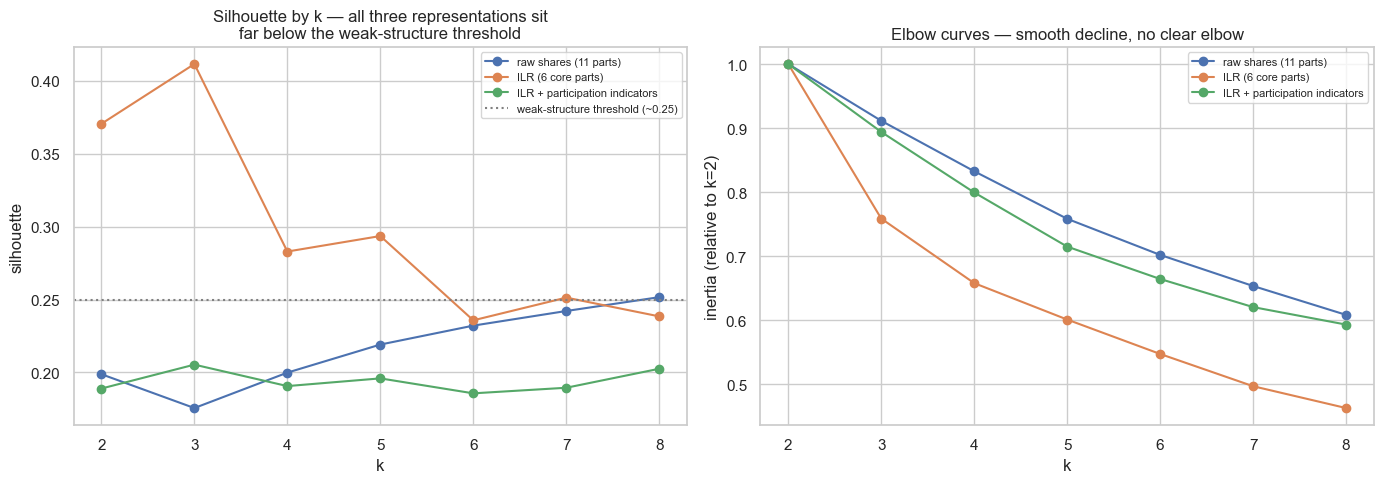

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in REPRESENTATIONS:
    sub = sweep[sweep["representation"] == name]
    axes[0].plot(sub["k"], sub["silhouette"], marker="o", label=name)
    axes[1].plot(sub["k"], sub["inertia"] / sub["inertia"].iloc[0], marker="o", label=name)
axes[0].axhline(0.25, color="grey", ls=":", label="weak-structure threshold (~0.25)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
axes[0].set_title("Silhouette by k — all three representations sit\nfar below the weak-structure threshold")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia (relative to k=2)")
axes[1].set_title("Elbow curves — smooth decline, no clear elbow")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../results/ihds_cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## Q1 — What spending personas emerge?

In [5]:
# Select the winning (representation, k) from the sweep rather than fixing it in advance.
best = sweep.loc[sweep["silhouette"].idxmax()]
BEST_REP, K = best["representation"], int(best["k"])
print(f"selected by silhouette: {BEST_REP}   k = {K}   silhouette = {best['silhouette']:.4f}")

Xs = StandardScaler().fit_transform(df[REPRESENTATIONS[BEST_REP]])
km = KMeans(n_clusters=K, n_init=20, random_state=42)
df["Persona"] = km.fit_predict(Xs)

profile = df.groupby("Persona").agg(
    n=("Persona", "size"),
    median_income=("INCOME", "median"),
    median_hh_size=("Household_Size", "median"),
    goal_met=("Goal_Met", "mean"),
    median_savings_rate=("Savings_Rate", "median"),
)
profile["pct_of_sample"] = (profile["n"] / len(df) * 100).round(1)
print("\nPersona profile:")
print(profile.round(4).to_string())

print("\nMean expense share by persona (the spending signature):")
sig = df.groupby("Persona")[SHARE_COLS].mean().T
sig.index = [i.replace("_Share", "") for i in sig.index]
print(sig.round(3).to_string())

selected by silhouette: ILR (6 core parts)   k = 3   silhouette = 0.4115



Persona profile:
             n  median_income  median_hh_size  goal_met  median_savings_rate  pct_of_sample
Persona                                                                                    
0         4876        48820.0             4.0    0.3123              -0.1194           11.7
1        28937        78700.0             5.0    0.3008              -0.1452           69.7
2         7703        84340.0             4.0    0.3930               0.0347           18.6

Mean expense share by persona (the spending signature):
Persona                0      1      2
Groceries          0.540  0.448  0.470
Eating_Out         0.005  0.009  0.010
Utilities          0.112  0.097  0.107
Rent               0.011  0.009  0.012
Transport          0.000  0.073  0.083
Healthcare         0.099  0.117  0.001
Education          0.031  0.049  0.052
Entertainment      0.003  0.007  0.008
Insurance          0.007  0.015  0.018
Clothing_Footwear  0.044  0.042  0.052
Miscellaneous      0.148  0.135  0.1

In [6]:
# The core parts include Transport (11.4% zero) and Healthcare (19.2% zero). Phase 2 replaced
# those zeros with a small delta before the log, which places them far out in log-ratio space.
# So: are the personas real allocation patterns, or just the zero PATTERN of the core parts?
print("Share of households recording ZERO spend, by persona and core part:")
zero_pat = df.groupby("Persona")[CORE].apply(lambda g: (g == 0).mean()).T
zero_pat.index = [i.replace("_Share", "") for i in zero_pat.index]
print(zero_pat.round(3).to_string())

core_zero_signature = df.groupby("Persona")[CORE].apply(lambda g: (g == 0).mean().round(0).astype(int).astype(str).str.cat())
print("\nzero-pattern signature per persona (1 = category absent for ~all members):")
print(core_zero_signature.to_string())

from sklearn.metrics import adjusted_rand_score as _ari
zero_key = (df[CORE] == 0).astype(int).astype(str).agg("".join, axis=1)
print(f"\nadjusted Rand index between personas and the raw zero-pattern of the core parts: "
      f"{_ari(df['Persona'], zero_key.factorize()[0]):.4f}")
print("(near 1 => the clustering is keyed on WHICH categories are missing, not on how the")
print(" present categories are allocated)")

print("\nParticipation rates by persona (share of households spending anything at all):")
part = df.groupby("Persona")[INDICATORS].mean().T
part.index = [i.replace("Spends_On_", "") for i in part.index]
print(part.round(3).to_string())

print("\nComposition by area type (row %):")
print((pd.crosstab(df["Persona"], df["Area_Type"], normalize="index") * 100).round(1).to_string())

print("\nComposition by occupation (row %):")
print((pd.crosstab(df["Persona"], df["Occupation"], normalize="index") * 100).round(1).to_string())

Share of households recording ZERO spend, by persona and core part:
Persona                0      1      2
Groceries          0.001  0.000  0.001
Utilities          0.004  0.001  0.002
Transport          0.956  0.003  0.000
Healthcare         0.246  0.002  0.868
Clothing_Footwear  0.030  0.014  0.004
Miscellaneous      0.000  0.001  0.000

zero-pattern signature per persona (1 = category absent for ~all members):
Persona
0    001000
1    000000
2    000100

adjusted Rand index between personas and the raw zero-pattern of the core parts: 0.8584
(near 1 => the clustering is keyed on WHICH categories are missing, not on how the
 present categories are allocated)

Participation rates by persona (share of households spending anything at all):
Persona            0      1      2
Eating_Out     0.118  0.303  0.300
Rent           0.091  0.094  0.105
Education      0.514  0.664  0.637
Entertainment  0.153  0.338  0.299
Insurance      0.111  0.281  0.294

Composition by area type (row %):
Area_Ty

## Q3 — Do the personas correlate meaningfully with `Goal_Met`?

In [7]:
ct = pd.crosstab(df["Persona"], df["Goal_Met"])
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print("Goal_Met by persona:")
summary = pd.DataFrame({
    "n": ct.sum(axis=1),
    "goal_met_rate": df.groupby("Persona")["Goal_Met"].mean(),
    "median_income": df.groupby("Persona")["INCOME"].median(),
})
print(summary.round(4).to_string())
print(f"\noverall Goal_Met rate: {df['Goal_Met'].mean():.4f}")
print(f"spread across personas: {summary['goal_met_rate'].max() - summary['goal_met_rate'].min():.4f}")
print(f"\nchi2 = {chi2:.1f}   p = {p:.3g}   Cramer's V = {cramers_v:.4f}")
print("(Cramer's V: 0.1 weak, 0.3 moderate, 0.5 strong)")

Goal_Met by persona:
             n  goal_met_rate  median_income
Persona                                     
0         4876         0.3123        48820.0
1        28937         0.3008        78700.0
2         7703         0.3930        84340.0

overall Goal_Met rate: 0.3193
spread across personas: 0.0921

chi2 = 238.8   p = 1.36e-52   Cramer's V = 0.0758
(Cramer's V: 0.1 weak, 0.3 moderate, 0.5 strong)


In [8]:
# Phase 5 found spending mix is only 26.7% of model attribution while income alone is 38.4%.
# So: do the personas carry information about the outcome BEYOND income?
df["Income_Decile"] = pd.qcut(df["INCOME"], 10, labels=False)

within = df.groupby(["Income_Decile", "Persona"])["Goal_Met"].mean().unstack()
print("Goal_Met rate by income decile x persona:")
print(within.round(3).to_string())

spread_raw = summary["goal_met_rate"].max() - summary["goal_met_rate"].min()
spread_within = within.max(axis=1).sub(within.min(axis=1)).mean()
print(f"\nraw spread across personas:                    {spread_raw:.4f}")
print(f"mean spread across personas WITHIN income decile: {spread_within:.4f}")
print(f"proportion of the persona effect surviving the income control: "
      f"{spread_within / spread_raw:.1%}")

# How much of persona membership is just income?
from sklearn.metrics import adjusted_rand_score
income_groups = pd.qcut(df["INCOME"], K, labels=False)
ari_income = adjusted_rand_score(df["Persona"], income_groups)
print(f"\nadjusted Rand index between personas and income {K}-tiles: {ari_income:.4f}")
print("(0 = independent, 1 = identical partitions)")

Goal_Met rate by income decile x persona:
Persona            0      1      2
Income_Decile                     
0              0.051  0.009  0.030
1              0.129  0.031  0.078
2              0.175  0.051  0.123
3              0.261  0.105  0.231
4              0.362  0.169  0.309
5              0.472  0.249  0.368
6              0.572  0.345  0.431
7              0.789  0.466  0.569
8              0.816  0.636  0.683
9              0.911  0.835  0.811

raw spread across personas:                    0.0921
mean spread across personas WITHIN income decile: 0.1668
proportion of the persona effect surviving the income control: 181.0%



adjusted Rand index between personas and income 3-tiles: 0.0057
(0 = independent, 1 = identical partitions)


## Summary figure and artifacts

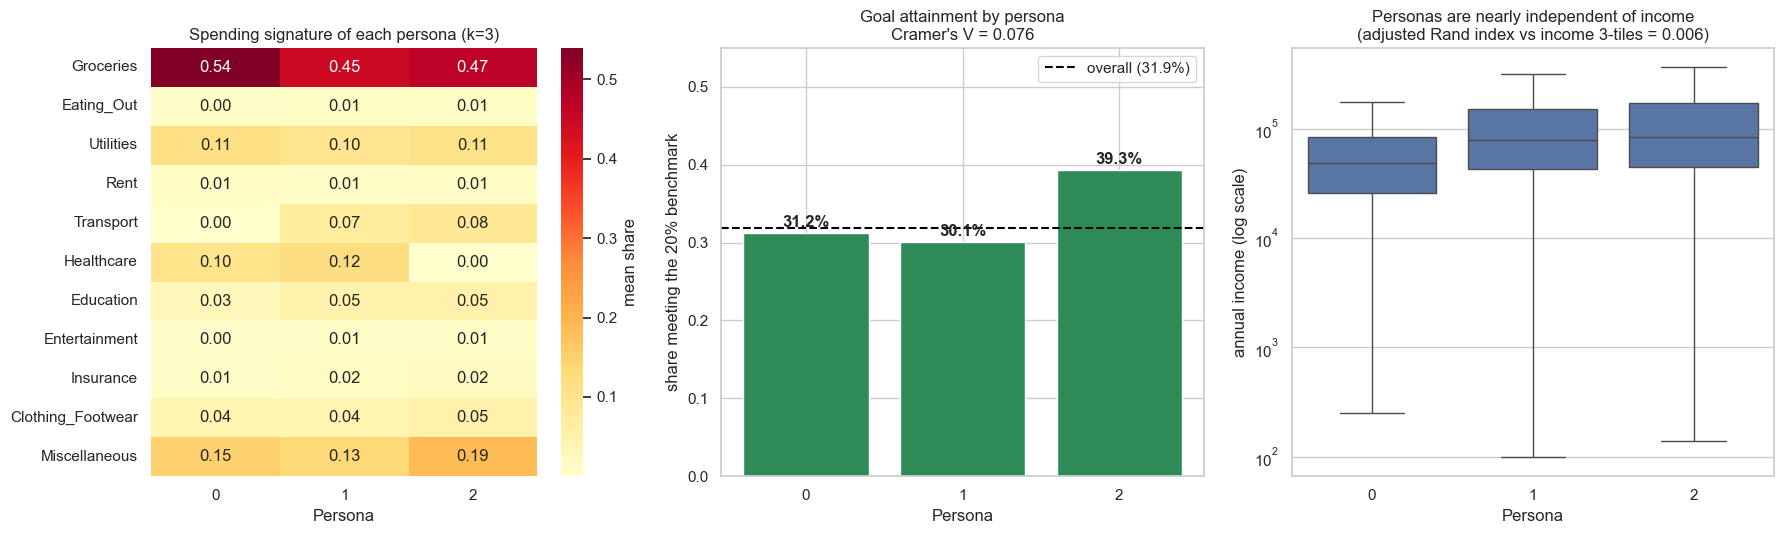

wrote ../results/ihds_persona_profiles.csv and ihds_personas.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Spending signature heatmap
ax = axes[0]
sns.heatmap(sig, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "mean share"}, ax=ax)
ax.set_title(f"Spending signature of each persona (k={K})")
ax.set_xlabel("Persona")

# 2. Goal_Met by persona
ax = axes[1]
bars = ax.bar(summary.index.astype(str), summary["goal_met_rate"], color="seagreen")
ax.axhline(df["Goal_Met"].mean(), color="black", ls="--",
           label=f"overall ({df['Goal_Met'].mean():.1%})")
for i, v in enumerate(summary["goal_met_rate"]):
    ax.annotate(f"{v:.1%}", (i, v + 0.008), ha="center", fontweight="bold")
ax.set_ylim(0, max(0.55, summary["goal_met_rate"].max() * 1.25))
ax.set_xlabel("Persona"); ax.set_ylabel("share meeting the 20% benchmark")
ax.set_title(f"Goal attainment by persona\nCramer's V = {cramers_v:.3f}")
ax.legend()

# 3. Persona vs income
ax = axes[2]
sns.boxplot(data=df, x="Persona", y="INCOME", ax=ax, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("annual income (log scale)")
ax.set_title(f"Personas are nearly independent of income\n"
             f"(adjusted Rand index vs income {K}-tiles = {ari_income:.3f})")

plt.tight_layout()
plt.savefig("../results/ihds_personas.png", dpi=150, bbox_inches="tight")
plt.show()

out = profile.join(sig.T)
out.to_csv("../results/ihds_persona_profiles.csv")
print("wrote ../results/ihds_persona_profiles.csv and ihds_personas.png")